In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/moonknightmarvel/paysim/paysim.csv


In [2]:
import pandas as pd

path = "/kaggle/input/datasets/moonknightmarvel/paysim/paysim.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print()
print(df.head())
print()
print(df["isFraud"].value_counts())

Shape: (6362620, 11)

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [3]:
!pip install xgboost shap joblib

In [4]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier

In [5]:
os.makedirs("outputs", exist_ok=True)
print("Created outputs folder")

Created outputs folder


In [6]:
print(os.listdir("."))

['.virtual_documents', 'outputs']


In [7]:
import pandas as pd

path = "/kaggle/input/datasets/moonknightmarvel/paysim/paysim.csv"
df = pd.read_csv(path)

print("Original shape:", df.shape)
print(df.head())

Original shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [8]:
# Chỉ giữ các giao dịch liên quan mạnh đến gian lận
df = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

print("Filtered shape:", df.shape)
print(df["type"].value_counts())
print(df["isFraud"].value_counts())

Filtered shape: (2770409, 11)
type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [9]:
# Số tiền thực sự bị trừ khỏi tài khoản gửi
df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

# Số tiền thực sự tăng ở tài khoản nhận
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

# Giờ giao dịch mô phỏng từ step
df["hour"] = df["step"] % 24

# Tài khoản gửi bị rút về 0 sau giao dịch
df["orig_drained"] = (df["newbalanceOrig"] == 0).astype(int)

# Tài khoản nhận trước đó chưa có số dư
df["new_destination"] = (df["oldbalanceDest"] == 0).astype(int)

# Tỷ lệ amount so với số dư ban đầu của người gửi
df["amount_to_balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

print("Feature engineering completed.")

Feature engineering completed.


In [10]:
feature_columns = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_diff",
    "dest_balance_diff",
    "hour",
    "orig_drained",
    "new_destination",
    "amount_to_balance_ratio"
]

target_column = "isFraud"

In [11]:
X = df[feature_columns].copy()
y = df[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud ratio:", y.mean())

X shape: (2770409, 11)
y shape: (2770409,)
Fraud ratio: 0.002964544224336551


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2216327, 11)
Test : (554082, 11)


In [13]:
import json

with open("outputs/feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved outputs/feature_columns.json")

Saved outputs/feature_columns.json


huấn luyện mô hình xgboot

In [14]:
# Tính tỷ lệ non-fraud / fraud
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 2209757
Positive samples: 6570
scale_pos_weight: 336.34048706240486


In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [16]:
model.fit(X_train, y_train)
print("XGBoost training completed.")

XGBoost training completed.


In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [18]:
from sklearn.metrics import roc_auc_score, classification_report

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)
print()
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9987048305238233

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.99      1.00      0.99      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [19]:
import joblib

joblib.dump(model, "outputs/model.pkl")
print("Saved outputs/model.pkl")

Saved outputs/model.pkl


In [20]:
import json

metrics = {
    "roc_auc": float(auc),
    "scale_pos_weight": float(scale_pos_weight),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "num_features": int(X_train.shape[1])
}

with open("outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs/metrics.json")

Saved outputs/metrics.json


In [21]:
import os
print(os.listdir("outputs"))

['model.pkl', 'metrics.json', 'feature_columns.json']


Dùng SHAP để xác định các feature quan trọng

In [22]:
import shap
import numpy as np
import pandas as pd
import json
import joblib

# Nếu notebook vừa restart, load lại model
model = joblib.load("outputs/model.pkl")

In [23]:
sample_size = min(20000, len(X_train))
X_sample = X_train.sample(sample_size, random_state=42)

print("Sample size for SHAP:", X_sample.shape)

Sample size for SHAP: (20000, 11)


In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP calculation completed.")

SHAP calculation completed.


In [25]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(10))

                    feature  mean_abs_shap
10  amount_to_balance_ratio       6.235590
3            oldbalanceDest       1.400759
8              orig_drained       1.117523
5         orig_balance_diff       1.056199
0                    amount       1.001109
4            newbalanceDest       0.791704
7                      hour       0.763471
6         dest_balance_diff       0.678189
1             oldbalanceOrg       0.648965
2            newbalanceOrig       0.327344


In [26]:
TOP_K = 8

important_features = (
    importance_df["feature"]
    .head(TOP_K)
    .tolist()
)

print("Important features:")
print(important_features)

Important features:
['amount_to_balance_ratio', 'oldbalanceDest', 'orig_drained', 'orig_balance_diff', 'amount', 'newbalanceDest', 'hour', 'dest_balance_diff']


In [27]:
# Lưu toàn bộ bảng SHAP summary
importance_df.to_csv(
    "outputs/shap_summary.csv",
    index=False
)

# Lưu danh sách feature quan trọng
with open("outputs/important_features.json", "w") as f:
    json.dump(important_features, f, indent=2)

print("Saved outputs/shap_summary.csv")
print("Saved outputs/important_features.json")

Saved outputs/shap_summary.csv
Saved outputs/important_features.json


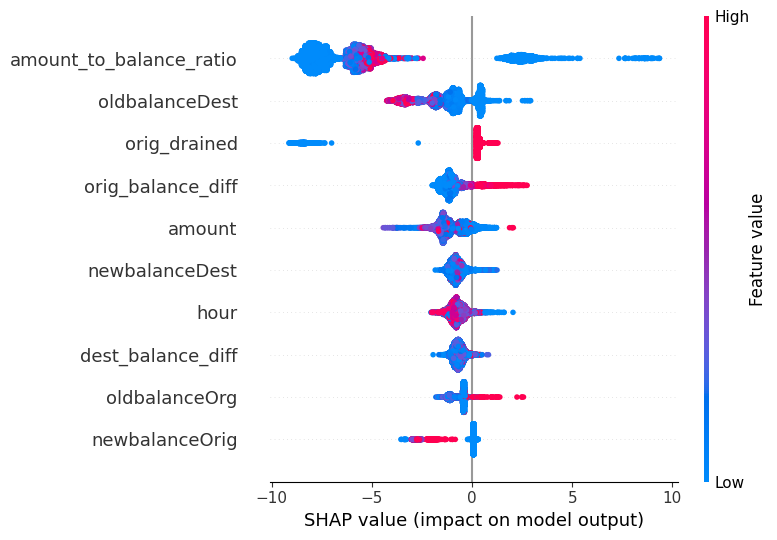

In [28]:
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=10
)

rule base

In [29]:
import json
import joblib

with open("outputs/important_features.json", "r") as f:
    important_features = json.load(f)

print("Important features:")
print(important_features)

Important features:
['amount_to_balance_ratio', 'oldbalanceDest', 'orig_drained', 'orig_balance_diff', 'amount', 'newbalanceDest', 'hour', 'dest_balance_diff']


In [30]:
X_tree_train = X_train[important_features].copy()
X_tree_test = X_test[important_features].copy()

print("Tree train shape:", X_tree_train.shape)

Tree train shape: (2216327, 8)


In [31]:
from sklearn.tree import DecisionTreeClassifier

rule_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

rule_tree.fit(X_tree_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [32]:
joblib.dump(rule_tree, "outputs/rule_tree.pkl")
print("Saved outputs/rule_tree.pkl")

Saved outputs/rule_tree.pkl


In [33]:
from sklearn.tree import _tree

def extract_rules_from_tree(tree_model, feature_names):
    tree_ = tree_model.tree_
    rules = []

    def recurse(node, conditions):
        # Nếu là node lá
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            values = tree_.value[node][0]
            total = values.sum()
            fraud_prob = values[1] / total if total > 0 else 0

            if fraud_prob > 0.5:
                rules.append({
                    "name": f"rule_{len(rules) + 1}",
                    "conditions": conditions.copy(),
                    "fraud_probability": float(fraud_prob),
                    "support": int(total)
                })
            return

        feature = feature_names[tree_.feature[node]]
        threshold = float(tree_.threshold[node])

        # Nhánh trái: <= threshold
        recurse(
            node=tree_.children_left[node],
            conditions=conditions + [[feature, "<=", threshold]]
        )

        # Nhánh phải: > threshold
        recurse(
            node=tree_.children_right[node],
            conditions=conditions + [[feature, ">", threshold]]
        )

    recurse(0, [])
    return rules

In [34]:
extracted_rules = extract_rules_from_tree(
    rule_tree,
    important_features
)

print("Number of extracted rules:", len(extracted_rules))

for rule in extracted_rules[:7]:
    print(rule)

Number of extracted rules: 7
{'name': 'rule_1', 'conditions': [['amount_to_balance_ratio', '<=', 1.0000026226043701], ['orig_drained', '<=', 0.5], ['amount', '<=', 990691.0], ['amount_to_balance_ratio', '>', 0.9996448755264282]], 'fraud_probability': 0.9333963269138735, 'support': 1}
{'name': 'rule_2', 'conditions': [['amount_to_balance_ratio', '<=', 1.0000026226043701], ['orig_drained', '<=', 0.5], ['amount', '>', 990691.0], ['newbalanceDest', '<=', 849772.21875]], 'fraud_probability': 0.9999524314213776, 'support': 1}
{'name': 'rule_3', 'conditions': [['amount_to_balance_ratio', '<=', 1.0000026226043701], ['orig_drained', '>', 0.5], ['orig_balance_diff', '<=', 1147.8050537109375]], 'fraud_probability': 0.9999393265877367, 'support': 1}
{'name': 'rule_4', 'conditions': [['amount_to_balance_ratio', '<=', 1.0000026226043701], ['orig_drained', '>', 0.5], ['orig_balance_diff', '>', 1147.8050537109375], ['dest_balance_diff', '<=', 610.4000244140625]], 'fraud_probability': 1.0, 'support': 1

In [35]:
with open("outputs/extracted_rules.json", "w") as f:
    json.dump(extracted_rules, f, indent=2)

print("Saved outputs/extracted_rules.json")

Saved outputs/extracted_rules.json


Backtest thống kê các luật và chọn ra những luật

In [36]:
import json
import numpy as np
import pandas as pd

with open("outputs/extracted_rules.json", "r") as f:
    extracted_rules = json.load(f)

print("Extracted rules:", len(extracted_rules))

Extracted rules: 7


In [37]:
def evaluate_condition(series, operator, threshold):
    if operator == "<=":
        return series <= threshold
    elif operator == ">":
        return series > threshold
    elif operator == "==":
        return series == threshold
    else:
        raise ValueError(f"Unsupported operator: {operator}")

In [38]:
def apply_rule(df, rule):
    mask = pd.Series(True, index=df.index)

    for feature, operator, threshold in rule["conditions"]:
        mask &= evaluate_condition(
            df[feature],
            operator,
            threshold
        )

    return mask

In [39]:
base_rate = y.mean()   # Tỷ lệ fraud chung

results = []
validated_rules = []

MIN_PRECISION = 0.80
MIN_SUPPORT = 50
MIN_LIFT = 5.0

for rule in extracted_rules:
    mask = apply_rule(X, rule)

    support = int(mask.sum())

    if support == 0:
        continue

    fraud_count = int(y[mask].sum())
    precision = fraud_count / support
    recall = fraud_count / y.sum()
    lift = precision / base_rate if base_rate > 0 else 0

    result = {
        "name": rule["name"],
        "support": support,
        "fraud_count": fraud_count,
        "precision": precision,
        "recall": recall,
        "lift": lift,
        "fraud_probability": rule["fraud_probability"]
    }

    results.append(result)

    # Chỉ giữ các luật đạt tiêu chí
    if (
        precision >= MIN_PRECISION
        and support >= MIN_SUPPORT
        and lift >= MIN_LIFT
    ):
        validated_rule = rule.copy()

        # Trọng số cho Rule Engine (0 → 1)
        validated_rule["precision"] = precision
        validated_rule["recall"] = recall
        validated_rule["lift"] = lift
        validated_rule["weight"] = min(1.0, precision)

        validated_rules.append(validated_rule)

In [40]:
rule_backtest_df = pd.DataFrame(results)
rule_backtest_df = rule_backtest_df.sort_values(
    "precision",
    ascending=False
)

print(rule_backtest_df.head(10))

     name  support  fraud_count  precision    recall        lift  \
3  rule_4     3912         3912   1.000000  0.476318  337.319981   
4  rule_5     4048         4048   1.000000  0.492877  337.319981   
1  rule_2      158          156   0.987342  0.018994  333.050107   
2  rule_3       65           64   0.984615  0.007793  332.130442   
0  rule_1       62            2   0.032258  0.000244   10.881290   
6  rule_7       72            2   0.027778  0.000244    9.369999   
5  rule_6     1711           16   0.009351  0.001948    3.154366   

   fraud_probability  
3           1.000000  
4           1.000000  
1           0.999952  
2           0.999939  
0           0.933396  
6           0.933396  
5           0.771200  


In [41]:
rule_backtest_df.to_csv(
    "outputs/rule_backtest.csv",
    index=False
)

print("Saved outputs/rule_backtest.csv")

Saved outputs/rule_backtest.csv


In [42]:
with open("outputs/validated_rules.json", "w") as f:
    json.dump(validated_rules, f, indent=2)

print("Validated rules:", len(validated_rules))
print("Saved outputs/validated_rules.json")

Validated rules: 4
Saved outputs/validated_rules.json


In [43]:
for rule in validated_rules[:3]:
    print(json.dumps(rule, indent=2))

{
  "name": "rule_2",
  "conditions": [
    [
      "amount_to_balance_ratio",
      "<=",
      1.0000026226043701
    ],
    [
      "orig_drained",
      "<=",
      0.5
    ],
    [
      "amount",
      ">",
      990691.0
    ],
    [
      "newbalanceDest",
      "<=",
      849772.21875
    ]
  ],
  "fraud_probability": 0.9999524314213776,
  "support": 1,
  "precision": 0.9873417721518988,
  "recall": 0.018994277365152808,
  "lift": 333.05010734756723,
  "weight": 0.9873417721518988
}
{
  "name": "rule_3",
  "conditions": [
    [
      "amount_to_balance_ratio",
      "<=",
      1.0000026226043701
    ],
    [
      "orig_drained",
      ">",
      0.5
    ],
    [
      "orig_balance_diff",
      "<=",
      1147.8050537109375
    ]
  ],
  "fraud_probability": 0.9999393265877367,
  "support": 1,
  "precision": 0.9846153846153847,
  "recall": 0.007792524047242177,
  "lift": 332.1304423568639,
  "weight": 0.9846153846153847
}
{
  "name": "rule_4",
  "conditions": [
    [
      